In [ ]:
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display
from networkx.drawing.nx_agraph import graphviz_layout

In [ ]:
def KL(p, q):
  S = 0
  for i in range(len(p)):
    if p[i] != 0:
      S += p[i]*np.log(p[i]/q[i])
  return S

In [ ]:
# ----------------------------
# Step 1: Trace function
# ----------------------------
def bubble_sort_trace_from_state(init_state):
    """
    Simulates execution of Bubble Sort from an arbitrary initial state.
    Returns a list of state vectors at each step:
    [arr copy, i, j, swapped, PC]
    """
    arr_init = init_state
    trace = []

    # Make a copy of array so we don't modify original
    arr = list(arr_init)
    n = len(arr)
    i = 0
    j = 0
    swapped = False
    PC = 0

    while True:
        trace.append([arr.copy(), i, j, swapped, PC])

        if PC == 0:
            # Start of outer loop
            PC = 1

        elif PC == 1:
            if i >= n:
                PC = 7  # Halt
            else:
                swapped = False
                j = 0
                PC = 2

        elif PC == 2:
            # Inner loop
            if j >= n - i - 1:
                PC = 6  # End of outer loop iteration
            else:
                PC = 3  # Compare elements

        elif PC == 3:
            # Compare arr[j] and arr[j+1]
            if arr[j] > arr[j+1]:
                PC = 4
            else:
                PC = 5  # Skip swap

        elif PC == 4:
            # Swap
            arr[j], arr[j+1] = arr[j+1], arr[j]
            swapped = True
            PC = 5

        elif PC == 5:
            # Increment inner loop index
            j += 1
            PC = 2

        elif PC == 6:
            # End of outer loop iteration
            if not swapped:
                PC = 7  # Halt
            else:
                i += 1
                PC = 1

        elif PC == 7:
            # Halt
            trace.append([arr.copy(), i, j, swapped, PC])
            break

    return trace

# Example: initial state with outer loop i=0, inner loop j=0, swapped=True, PC=0
# trace_example = bubble_sort_trace_from_state([3,1,2])
# for t in trace_example:
#     print(t)


### I. n = 3 without repeating entries (permutations)

In [ ]:
# ----------------------------
# Step 2: Build the Graph for n = 3
# ----------------------------

# Generate traces for all input pairs (0-9)
all_states = []
state_traces = [] # This will now store flattened traces
n = 3
arr_perms = itertools.permutations(range(1, n+1))
for arr_initial in arr_perms:
    # Call the bubble sort trace function. The version in NK8hJEVTunNt
    # returns states as: [list of array elements, i, j, swapped, PC]
    trace_raw = bubble_sort_trace_from_state(list(arr_initial))

    current_trace_flattened = []
    for state in trace_raw:
        arr_part = list(state[0]) # Get the array as a list
        i_val = state[1]
        j_val = state[2]
        swapped_val = int(state[3]) # Convert boolean 'swapped' to int for numerical consistency
        pc_val = state[4]

        # Flatten the state into a single list of numbers
        flattened_state = arr_part + [i_val, j_val, swapped_val, pc_val]
        current_trace_flattened.append(flattened_state)

    state_traces.append(current_trace_flattened) # Store the flattened trace
    all_states.extend(current_trace_flattened) # Extend the master list with flattened states

# Now, all_states is a list of lists, where each inner list is a flat sequence of numbers.
# np.array(all_states) should now work correctly.
all_states = np.array(all_states)
be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
hashes = np.dot(all_states, be)
unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
hash_dict = {h: i for i, h in enumerate(unique_hashes)}

In [ ]:
# ----------------------------
# Step 3: Build adjacency matrix
# ----------------------------
G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)
pos_cen = []

global_idx = 0 # Initialize a counter for the index in the flattened all_states array

for trace in state_traces:
    L = len(trace)
    for u in range(L):
        # Get the unique hash index for the current state in the trace
        # It corresponds to the state at position `global_idx` in the `all_states` array.
        n1 = inverse_indices[global_idx]

        if u < L-1:
            # Get the unique hash index for the next state in the trace
            # It corresponds to the state at position `global_idx + 1` in the `all_states` array.
            n2 = inverse_indices[global_idx + 1]
        else:
            n2 = n1
            pos_cen.append(n1)

        G[n1, n2] = 1
        global_idx += 1 # Increment global_idx for the next state in all_states

In [ ]:
pos_cen = np.unique(pos_cen)

In [ ]:
# ----------------------------
# Step 4: Visualize with NetworkX
# ----------------------------

G_nx = nx.DiGraph()
for i in range(len(G)):
    for j in range(len(G)):
        if G[i, j] == 1:
            G_nx.add_edge(i, j)



In [ ]:
halting_nodes = []

for node in G_nx.nodes():
    out_edges = list(G_nx.out_edges(node))
    if len(out_edges) == 1 and out_edges[0][1] == node:
        halting_nodes.append(node)

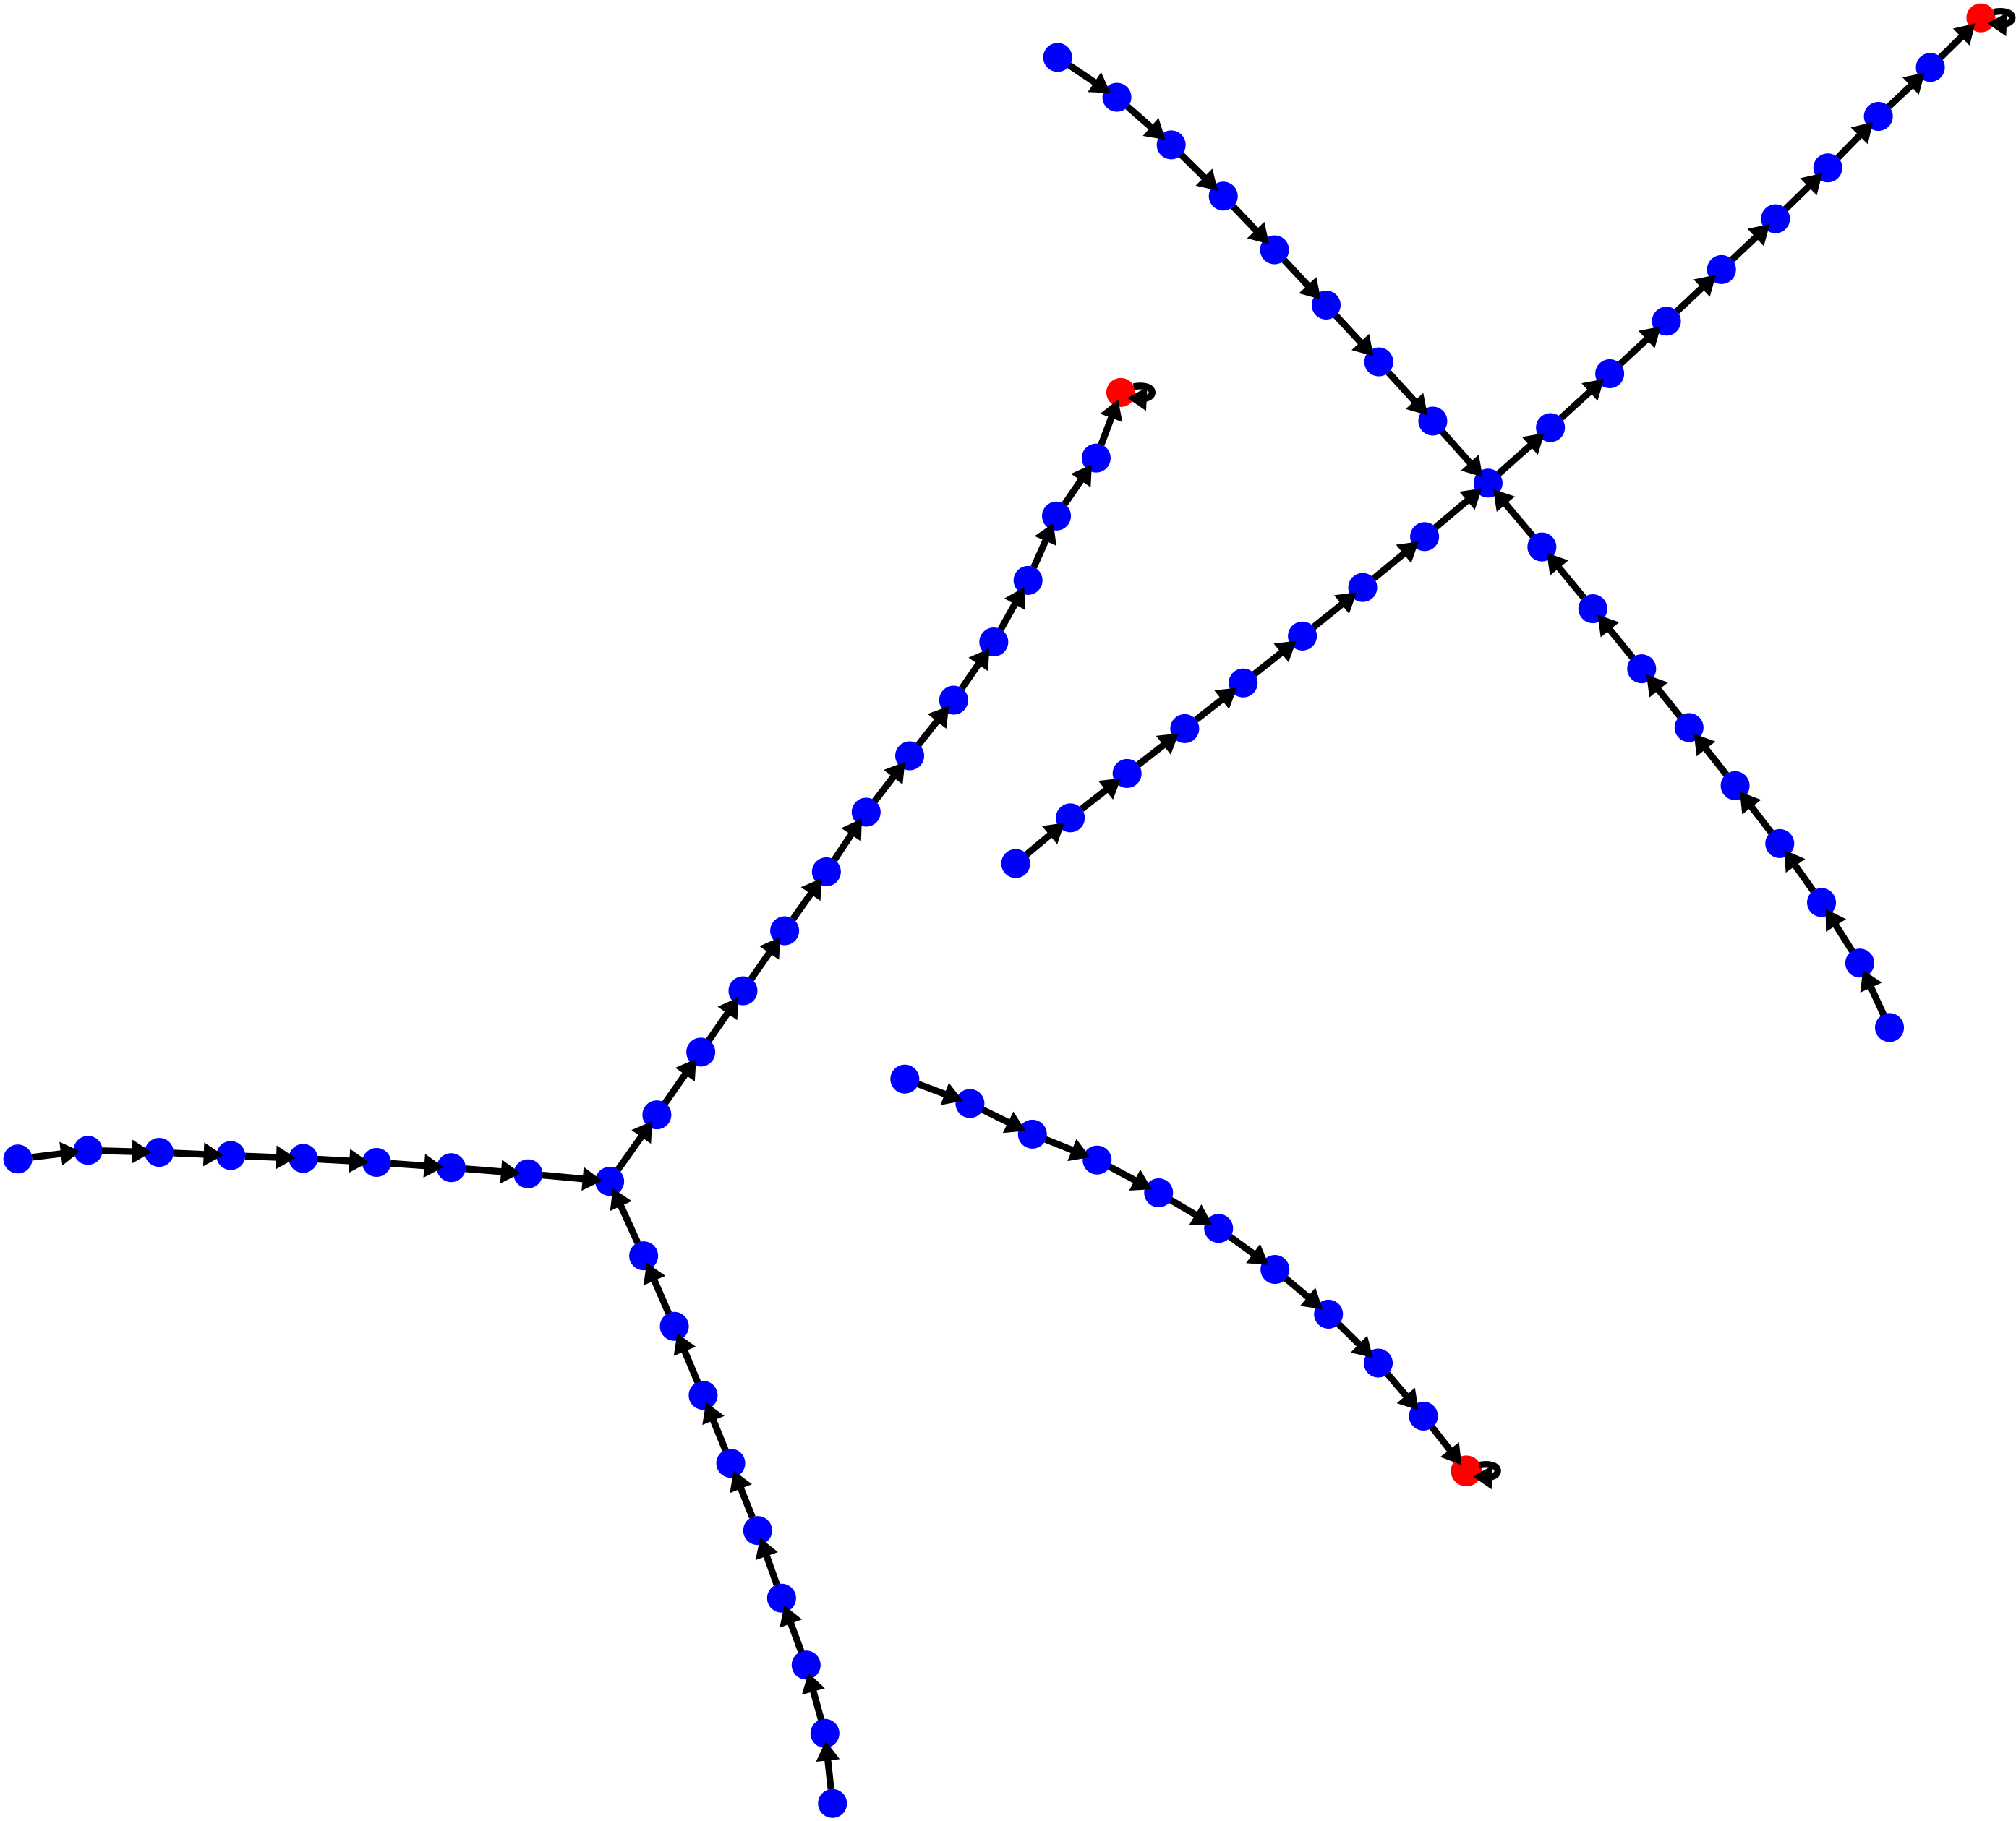

In [ ]:
for node in G_nx.nodes():
    is_halting = node in halting_nodes

    G_nx.nodes[node]['label'] = ''
    G_nx.nodes[node]['shape'] = 'circle'
    G_nx.nodes[node]['style'] = 'filled'
    G_nx.nodes[node]['fixedsize'] = 'true'
    G_nx.nodes[node]['width'] = '0.4'
    G_nx.nodes[node]['height'] = '0.4'

    if is_halting:
        G_nx.nodes[node]['fillcolor'] = 'red'
        G_nx.nodes[node]['color'] = 'red'
    else:
        G_nx.nodes[node]['fillcolor'] = 'blue'
        G_nx.nodes[node]['color'] = 'blue'
for u, v in G_nx.edges():
    G_nx[u][v]['penwidth'] = 7
    G_nx[u][v]['minlen'] = 6
p = nx.drawing.nx_pydot.to_pydot(G_nx)
p.set_prog('neato')
p.write_pdf('bubblesort_n3.pdf')
p.write_png('graph.png')
#G_nx.nodes[node]['penwidth'] = '3'

display(Image(filename='graph.png'))

### II. n = 4 without repeating entries (permutations)

In [ ]:
# ----------------------------
# REPEATING THE SAME CODE FOR n = 4
# ----------------------------

# ----------------------------
# Step 2: Build the Graph for n = 4
# ----------------------------

# Generate traces for all input pairs (0-9)
all_states = []
state_traces = [] # This will now store flattened traces
n = 4
arr_perms = itertools.permutations(range(1, n+1))
for arr_initial in arr_perms:
    # Call the bubble sort trace function. The version in NK8hJEVTunNt
    # returns states as: [list of array elements, i, j, swapped, PC]
    trace_raw = bubble_sort_trace_from_state(list(arr_initial))

    current_trace_flattened = []
    for state in trace_raw:
        arr_part = list(state[0]) # Get the array as a list
        i_val = state[1]
        j_val = state[2]
        swapped_val = int(state[3]) # Convert boolean 'swapped' to int for numerical consistency
        pc_val = state[4]

        # Flatten the state into a single list of numbers
        flattened_state = arr_part + [i_val, j_val, swapped_val, pc_val]
        current_trace_flattened.append(flattened_state)

    state_traces.append(current_trace_flattened) # Store the flattened trace
    all_states.extend(current_trace_flattened) # Extend the master list with flattened states

# Now, all_states is a list of lists, where each inner list is a flat sequence of numbers.
# np.array(all_states) should now work correctly.
all_states = np.array(all_states)
be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
hashes = np.dot(all_states, be)
unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
hash_dict = {h: i for i, h in enumerate(unique_hashes)}

In [ ]:
# ----------------------------
# Step 3: Build adjacency matrix
# ----------------------------
G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)
pos_cen = []

global_idx = 0 # Initialize a counter for the index in the flattened all_states array

for trace in state_traces:
    L = len(trace)
    for u in range(L):
        # Get the unique hash index for the current state in the trace
        # It corresponds to the state at position `global_idx` in the `all_states` array.
        n1 = inverse_indices[global_idx]

        if u < L-1:
            # Get the unique hash index for the next state in the trace
            # It corresponds to the state at position `global_idx + 1` in the `all_states` array.
            n2 = inverse_indices[global_idx + 1]
        else:
            n2 = n1
            pos_cen.append(n1)

        G[n1, n2] = 1
        global_idx += 1 # Increment global_idx for the next state in all_states

In [ ]:
pos_cen = np.unique(pos_cen)

In [ ]:
# ----------------------------
# Step 4: Visualize with NetworkX
# ----------------------------

G_nx = nx.DiGraph()
for i in range(len(G)):
    for j in range(len(G)):
        if G[i, j] == 1:
            G_nx.add_edge(i, j)



In [ ]:
halting_nodes = []

for node in G_nx.nodes():
    out_edges = list(G_nx.out_edges(node))
    if len(out_edges) == 1 and out_edges[0][1] == node:
        halting_nodes.append(node)

In [ ]:
node_colors = ['red' if n in halting_nodes else 'blue' for n in G_nx.nodes()]

In [ ]:
for node in G_nx.nodes():
    is_halting = node in halting_nodes

    G_nx.nodes[node]['label'] = ''
    G_nx.nodes[node]['shape'] = 'circle'
    G_nx.nodes[node]['style'] = 'filled'
    G_nx.nodes[node]['fixedsize'] = 'true'
    G_nx.nodes[node]['width'] = '0.5'
    G_nx.nodes[node]['height'] = '0.5'

    if is_halting:
        G_nx.nodes[node]['fillcolor'] = 'red'
        G_nx.nodes[node]['color'] = 'red'
        G_nx.nodes[node]['width'] = '0.8'
        G_nx.nodes[node]['height'] = '0.8'
    else:
        G_nx.nodes[node]['fillcolor'] = 'blue'
        G_nx.nodes[node]['color'] = 'blue'


In [ ]:
for u, v in G_nx.edges():
    G_nx[u][v]['penwidth'] = 10
    G_nx[u][v]['minlen'] = 150


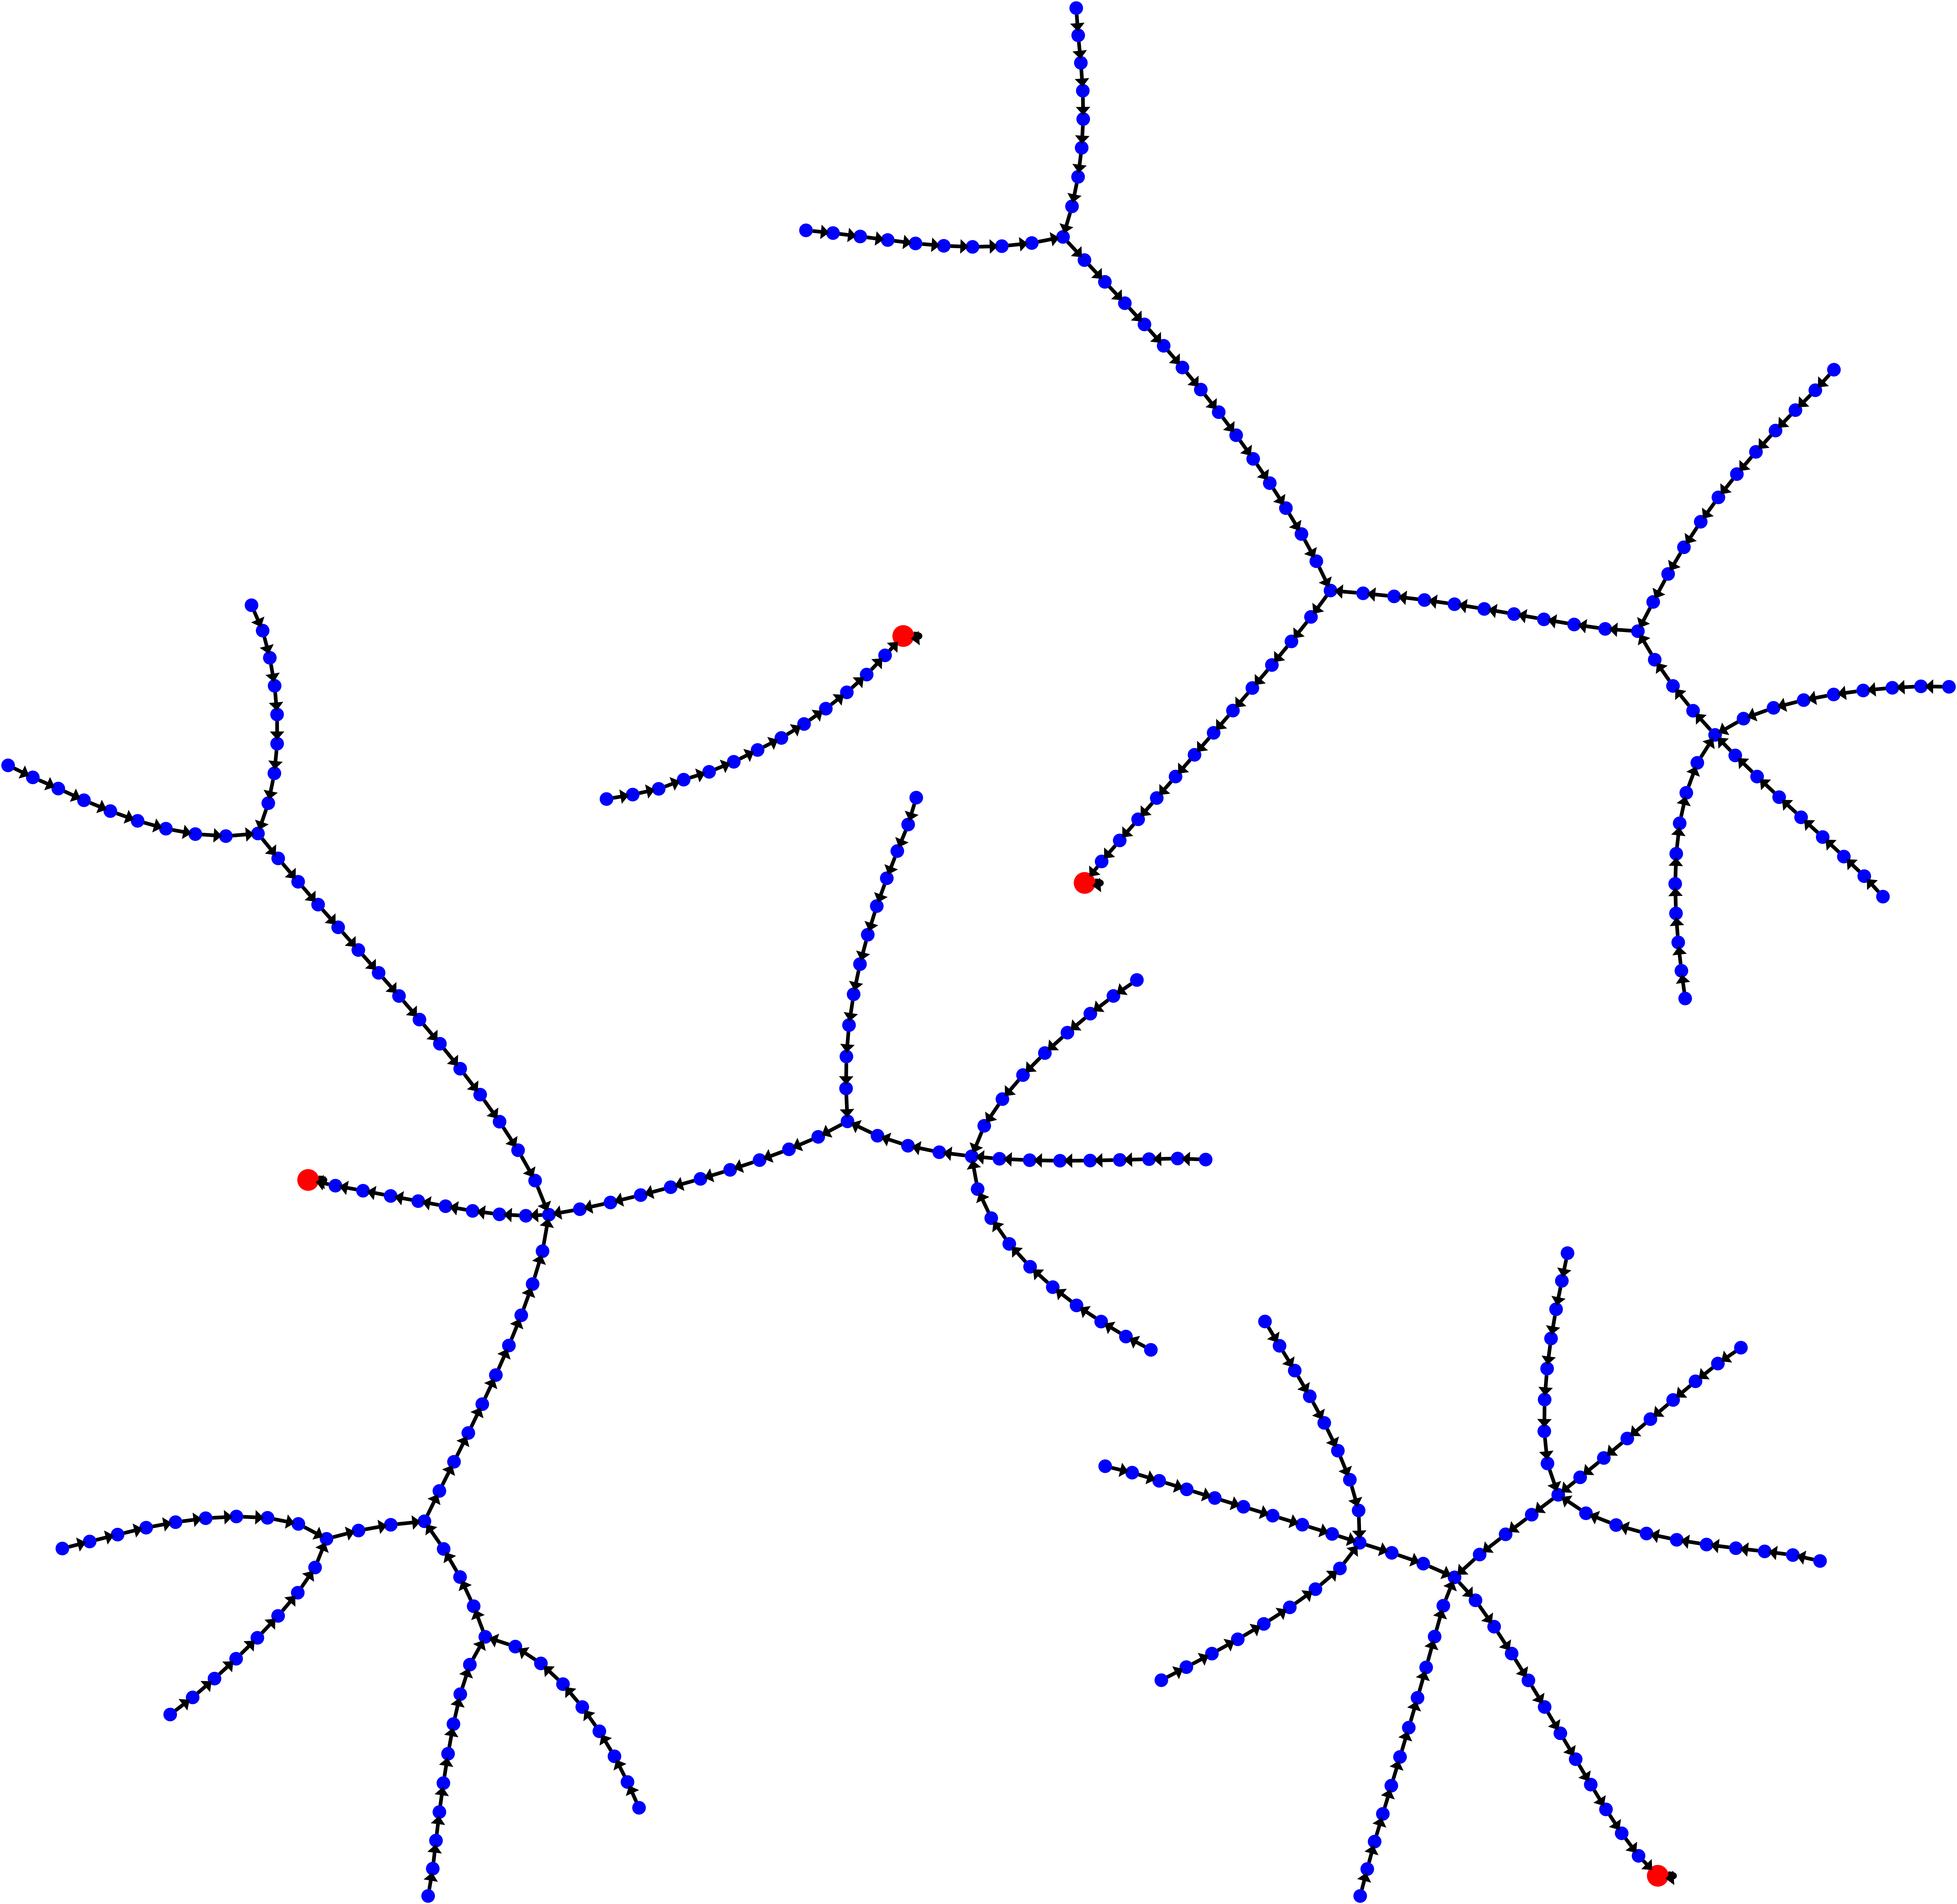

In [ ]:
p = nx.drawing.nx_pydot.to_pydot(G_nx)
p.set_prog('neato')
p.write_pdf('bubblesort_n4.pdf')
p.write_png('graph.png')
#G_nx.nodes[node]['penwidth'] = '3'

display(Image(filename='graph.png'))


### III n = 4 with REPEATED Entries

In [ ]:
# ----------------------------
# REPEATING THE SAME CODE FOR n = 4 with REPEATED Entries
# ----------------------------

# ----------------------------
# Step 2: Build the Graph for n = 4
# ----------------------------

# Generate traces for all input pairs (0-9)
all_states = []
state_traces = [] # This will now store flattened traces
n = 4
values = [1, 2, 3, 4]  # possible values for each slot
length = 4
arr_perms = list(itertools.product(values, repeat=length))
for arr_initial in arr_perms:
    # Call the bubble sort trace function. The version in NK8hJEVTunNt
    # returns states as: [list of array elements, i, j, swapped, PC]
    trace_raw = bubble_sort_trace_from_state(list(arr_initial))

    current_trace_flattened = []
    for state in trace_raw:
        arr_part = list(state[0]) # Get the array as a list
        i_val = state[1]
        j_val = state[2]
        swapped_val = int(state[3]) # Convert boolean 'swapped' to int for numerical consistency
        pc_val = state[4]

        # Flatten the state into a single list of numbers
        flattened_state = arr_part + [i_val, j_val, swapped_val, pc_val]
        current_trace_flattened.append(flattened_state)

    state_traces.append(current_trace_flattened) # Store the flattened trace
    all_states.extend(current_trace_flattened) # Extend the master list with flattened states

# Now, all_states is a list of lists, where each inner list is a flat sequence of numbers.
# np.array(all_states) should now work correctly.
all_states = np.array(all_states)
be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
hashes = np.dot(all_states, be)
unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
hash_dict = {h: i for i, h in enumerate(unique_hashes)}

In [ ]:
# ----------------------------
# Step 3: Build adjacency matrix
# ----------------------------
G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)
pos_cen = []

global_idx = 0 # Initialize a counter for the index in the flattened all_states array

for trace in state_traces:
    L = len(trace)
    for u in range(L):
        # Get the unique hash index for the current state in the trace
        # It corresponds to the state at position `global_idx` in the `all_states` array.
        n1 = inverse_indices[global_idx]

        if u < L-1:
            # Get the unique hash index for the next state in the trace
            # It corresponds to the state at position `global_idx + 1` in the `all_states` array.
            n2 = inverse_indices[global_idx + 1]
        else:
            n2 = n1
            pos_cen.append(n1)

        G[n1, n2] = 1
        global_idx += 1 # Increment global_idx for the next state in all_states

In [ ]:
pos_cen = np.unique(pos_cen)

In [ ]:
# ----------------------------
# Step 4: Visualize with NetworkX
# ----------------------------

G_nx = nx.DiGraph()
for i in range(len(G)):
    for j in range(len(G)):
        if G[i, j] == 1:
            G_nx.add_edge(i, j)



In [ ]:
halting_nodes = []

for node in G_nx.nodes():
    out_edges = list(G_nx.out_edges(node))
    if len(out_edges) == 1 and out_edges[0][1] == node:
        halting_nodes.append(node)

In [ ]:
node_colors = ['red' if n in halting_nodes else 'blue' for n in G_nx.nodes()]

In [ ]:
for node in G_nx.nodes():
    is_halting = node in halting_nodes

    G_nx.nodes[node]['label'] = ''
    G_nx.nodes[node]['shape'] = 'circle'
    G_nx.nodes[node]['style'] = 'filled'
    G_nx.nodes[node]['fixedsize'] = 'true'
    G_nx.nodes[node]['width'] = '0.15'
    G_nx.nodes[node]['height'] = '0.15'

    if is_halting:
        G_nx.nodes[node]['fillcolor'] = 'red'
        G_nx.nodes[node]['color'] = 'red'
        G_nx.nodes[node]['width'] = '0.2'
        G_nx.nodes[node]['height'] = '0.2'
    else:
        G_nx.nodes[node]['fillcolor'] = 'blue'
        G_nx.nodes[node]['color'] = 'blue'


In [ ]:
for u, v in G_nx.edges():
    G_nx[u][v]['penwidth'] = 1
    G_nx[u][v]['minlen'] = 15


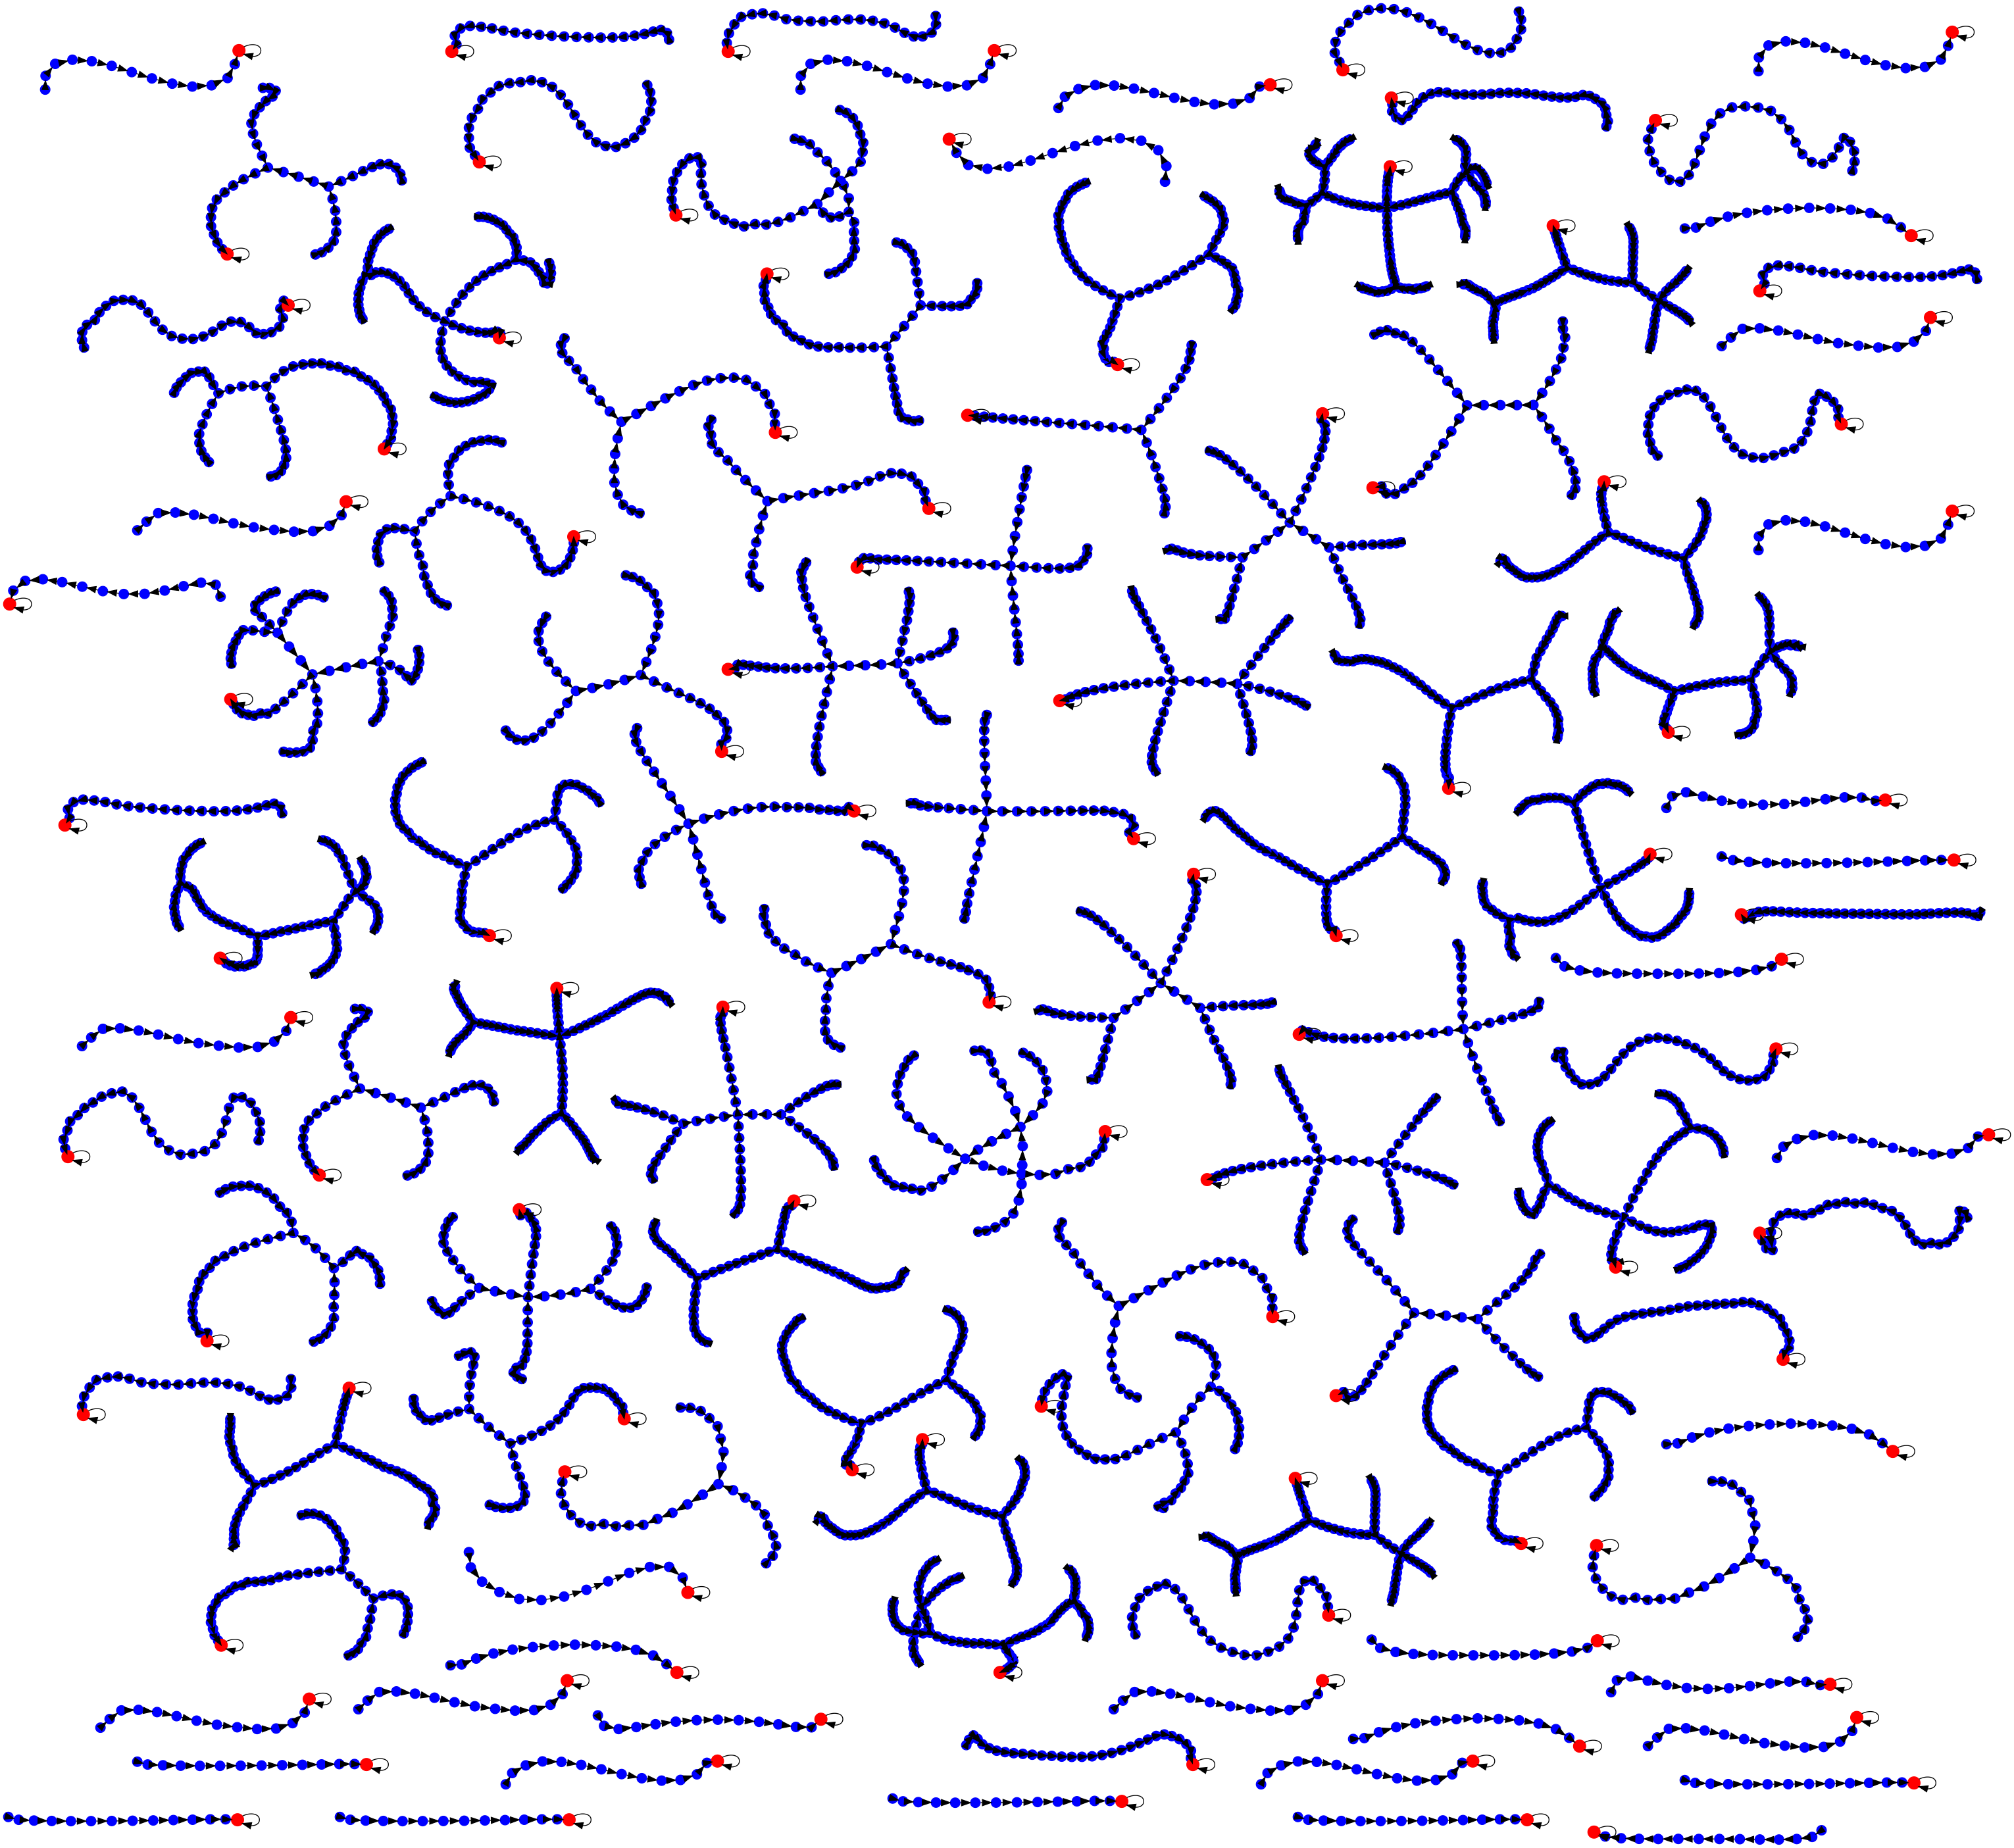

In [ ]:
p = nx.drawing.nx_pydot.to_pydot(G_nx)
p.set_prog('sfdp')
p.write_pdf('bubblesort_n4_comb.pdf')
p.write_png('graph.png')
#G_nx.nodes[node]['penwidth'] = '3'

display(Image(filename='graph.png'))